In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [14]:
df = pd.read_csv("Heart_disease_cleveland_new.csv")

print("First 5 Rows:")
print(df.head())


First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   0       145   233    1        2      150      0      2.3      2   
1   67    1   3       160   286    0        2      108      1      1.5      1   
2   67    1   3       120   229    0        2      129      1      2.6      1   
3   37    1   2       130   250    0        0      187      0      3.5      2   
4   41    0   1       130   204    0        2      172      0      1.4      0   

   ca  thal  target  
0   0     2       0  
1   3     1       1  
2   2     3       1  
3   0     1       0  
4   0     1       0  


In [15]:
print("\nDataset Shape:")
print(df.shape)



Dataset Shape:
(303, 14)


In [16]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [17]:
df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)



Shape after removing duplicates:
(303, 14)


In [18]:
X = df.drop("target", axis=1)
y = df["target"]

target_names = ["No Disease", "Disease"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (242, 13)
Testing Data: (61, 13)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


========== LOGISTIC REGRESSION ==========
Accuracy : 0.8688524590163934
Precision: 0.8125
Recall   : 0.9285714285714286
F1 Score : 0.8666666666666667


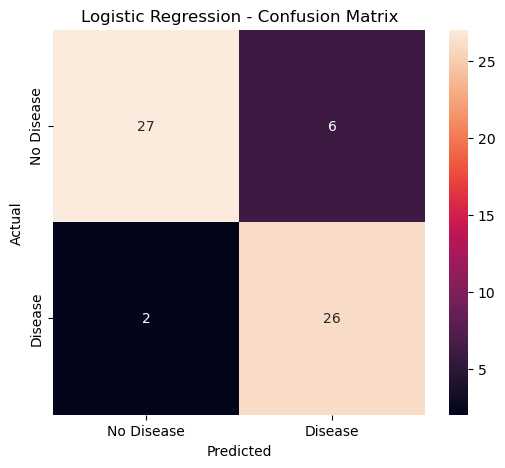

In [21]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("\n========== LOGISTIC REGRESSION ==========")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, zero_division=0))
print("Recall   :", recall_score(y_test, lr_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, lr_pred, zero_division=0))

# Logistic Regression Confusion Matrix

lr_cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




========== DECISION TREE ==========
Accuracy : 0.7868852459016393
Precision: 0.7419354838709677
Recall   : 0.8214285714285714
F1 Score : 0.7796610169491526


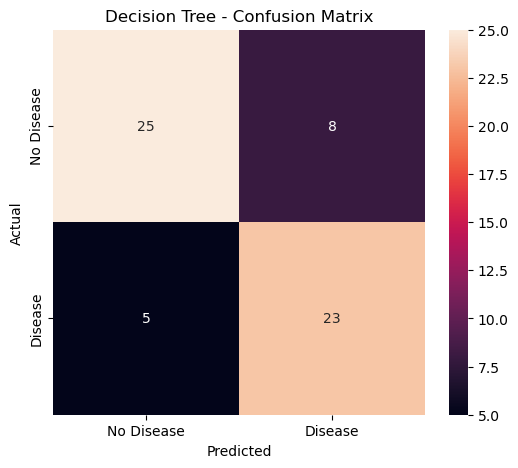

In [22]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\n========== DECISION TREE ==========")

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, zero_division=0))
print("Recall   :", recall_score(y_test, dt_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, dt_pred, zero_division=0))


# Decision Tree Confusion Matrix

dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

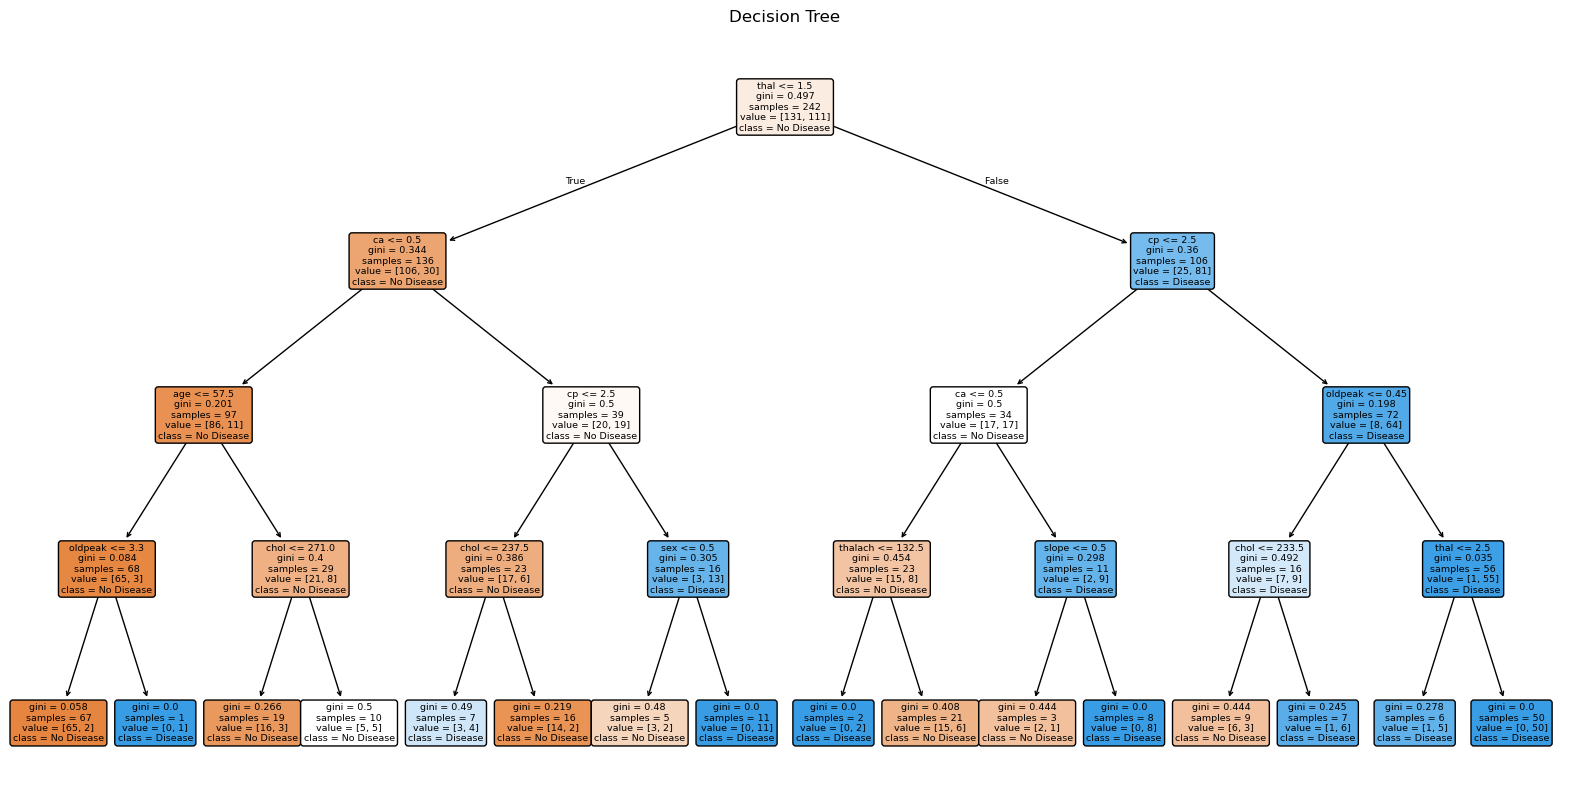

In [23]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree")
plt.show()


========== NAIVE BAYES ==========
Accuracy : 0.8688524590163934
Precision: 0.7941176470588235
Recall   : 0.9642857142857143
F1 Score : 0.8709677419354839


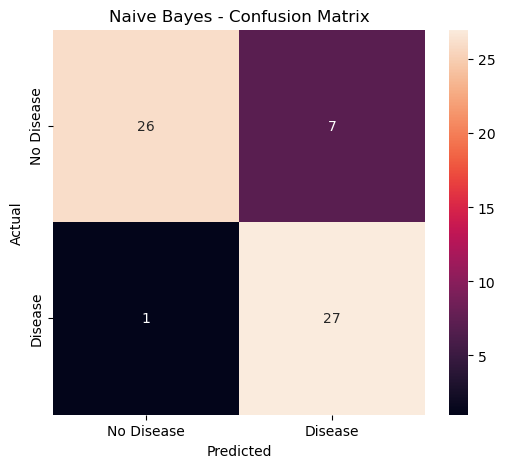

In [24]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)

print("\n========== NAIVE BAYES ==========")

print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred, zero_division=0))
print("Recall   :", recall_score(y_test, nb_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, nb_pred, zero_division=0))

# Naive Bayes Confusion Matrix

nb_cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, nb_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred, zero_division=0),
        precision_score(y_test, dt_pred, zero_division=0),
        precision_score(y_test, nb_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, lr_pred, zero_division=0),
        recall_score(y_test, dt_pred, zero_division=0),
        recall_score(y_test, nb_pred, zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred, zero_division=0),
        f1_score(y_test, dt_pred, zero_division=0),
        f1_score(y_test, nb_pred, zero_division=0)
    ]
})
print("\n========== MODEL COMPARISON ==========")
print(comparison)


========== MODEL COMPARISON ==========
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.868852   0.812500  0.928571  0.866667
1        Decision Tree  0.786885   0.741935  0.821429  0.779661
2          Naive Bayes  0.868852   0.794118  0.964286  0.870968


In [26]:
best_index = comparison["Recall"].idxmax()

best_model_name = comparison.loc[best_index, "Model"]
best_recall = comparison.loc[best_index, "Recall"]

print("\n========== BEST MODEL ==========")
print("Best Model:", best_model_name)
print("Best Recall:", best_recall)


========== BEST MODEL ==========
Best Model: Naive Bayes
Best Recall: 0.9642857142857143


In [28]:
# Taking one sample from the test dataset
new_sample = X_test.iloc[[0]]

if best_model_name == "Logistic Regression":

    sample = scaler.transform(new_sample)

    prediction = lr_model.predict(sample)[0]
    probability = lr_model.predict_proba(sample)[0]

elif best_model_name == "Decision Tree":

    prediction = dt_model.predict(new_sample)[0]
    probability = dt_model.predict_proba(new_sample)[0]

else:

    sample = scaler.transform(new_sample)

    prediction = nb_model.predict(sample)[0]
    probability = nb_model.predict_proba(sample)[0]
print("\n========== NEW SAMPLE PREDICTION ==========")

print("Best Model:", best_model_name)

print("Actual:",
      target_names[int(y_test.iloc[0])])

print("Prediction:",
      target_names[prediction])

print("No Disease Probability:",
      round(probability[0] * 100, 2), "%")

print("Disease Probability:",
      round(probability[1] * 100, 2), "%")


========== NEW SAMPLE PREDICTION ==========
Best Model: Naive Bayes
Actual: No Disease
Prediction: No Disease
No Disease Probability: 97.9 %
Disease Probability: 2.1 %
